# Image Processing with OpenCV Example: Real-time Face and Eye Detection from Camera

In [7]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
from collections import Counter # For charting detected objects


In [8]:


# Load pre-trained Haar cascade classifiers
# These XML files are usually included with OpenCV installation.
# You might need to adjust the path if they are not found.
# Common location example: C:\Program Files\Python39\Lib\site-packages\cv2\data\
face_cascade_path = cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
eye_cascade_path = cv2.data.haarcascades + 'haarcascade_eye.xml'

# Check if cascade files exist
if not os.path.exists(face_cascade_path):
    print(f"Error: Face cascade XML not found at {face_cascade_path}.")
    print("Please ensure you have OpenCV installed correctly and the Haar cascade files are accessible.")
    print("You can often find them in your Python site-packages/cv2/data/ directory.")
    exit()
if not os.path.exists(eye_cascade_path):
    print(f"Error: Eye cascade XML not found at {eye_cascade_path}.")
    exit()

face_cascade = cv2.CascadeClassifier(face_cascade_path)
eye_cascade = cv2.CascadeClassifier(eye_cascade_path)


In [9]:

# Initialize video capture (0 is usually the default webcam)
cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("Error: Could not open video stream. Make sure your webcam is connected and not in use.")
    exit()

print("\nStarting real-time face and eye detection. Press 'q' to quit.")



Starting real-time face and eye detection. Press 'q' to quit.



Video stream ended.

Generating detection charts based on the first 100 processed frames...


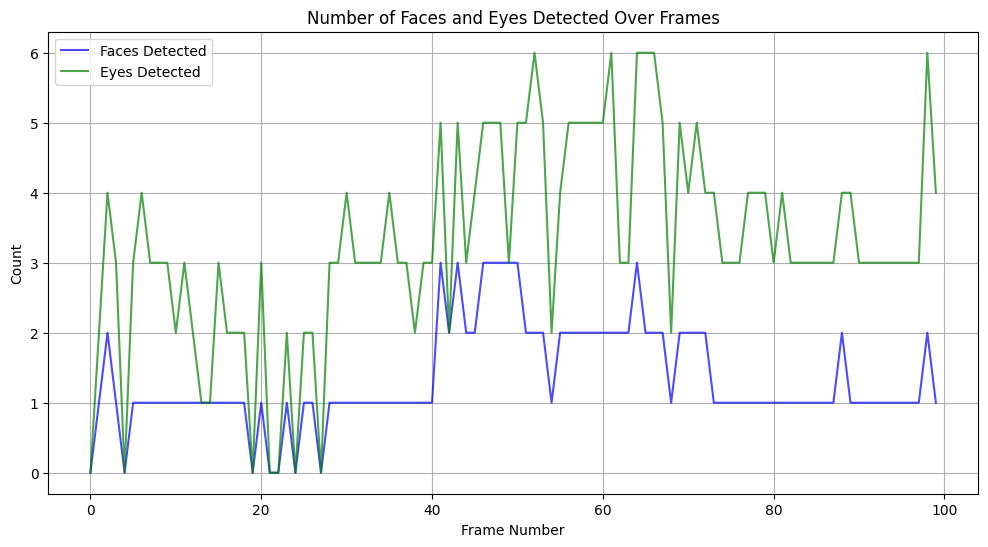

Plot generated: Time-series of face and eye detections.


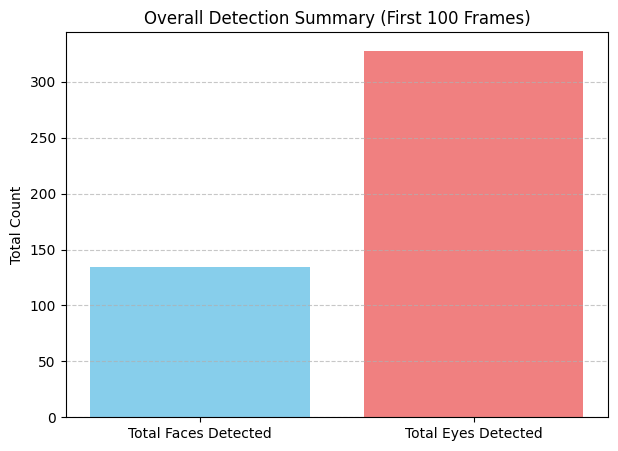

Plot generated: Bar chart of total detected faces and eyes.


In [10]:

# List to store detected object counts per frame for charting later
detection_counts_per_frame = []
max_frames_to_log = 100 # Log detections for this many frames for analysis

try:
    frame_count = 0
    while True:
        ret, frame = cap.read() # Read a frame from the camera
        if not ret:
            print("Failed to grab frame, exiting...")
            break

        gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        # Detect faces
        faces = face_cascade.detectMultiScale(gray_frame, 1.3, 5)

        current_frame_detections = {'faces': 0, 'eyes': 0}

        for (x, y, w, h) in faces:
            cv2.rectangle(frame, (x, y), (x+w, y+h), (255, 0, 0), 2) # Blue rectangle for face
            current_frame_detections['faces'] += 1

            roi_gray = gray_frame[y:y+h, x:x+w]
            roi_color = frame[y:y+h, x:x+w]

            # Detect eyes within the face region
            eyes = eye_cascade.detectMultiScale(roi_gray)
            for (ex, ey, ew, eh) in eyes:
                cv2.rectangle(roi_color, (ex, ey), (ex+ew, ey+eh), (0, 255, 0), 2) # Green rectangle for eyes
                current_frame_detections['eyes'] += 1

        if frame_count < max_frames_to_log:
            detection_counts_per_frame.append(current_frame_detections)
            frame_count += 1

        # Display the resulting frame
        cv2.imshow('Live Face and Eye Detection (Press q to quit)', frame)

        # Break the loop if 'q' is pressed
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

finally:
    # Release the capture and destroy all windows
    cap.release()
    cv2.destroyAllWindows()
    print("\nVideo stream ended.")

# 7. Generate Charts and Graphs based on logged detections
if detection_counts_per_frame:
    print(f"\nGenerating detection charts based on the first {min(frame_count, max_frames_to_log)} processed frames...")

    face_counts = [d['faces'] for d in detection_counts_per_frame]
    eye_counts = [d['eyes'] for d in detection_counts_per_frame]
    frame_indices = list(range(len(detection_counts_per_frame)))

    plt.figure(figsize=(12, 6))
    plt.plot(frame_indices, face_counts, label='Faces Detected', color='blue', alpha=0.7)
    plt.plot(frame_indices, eye_counts, label='Eyes Detected', color='green', alpha=0.7)
    plt.title('Number of Faces and Eyes Detected Over Frames')
    plt.xlabel('Frame Number')
    plt.ylabel('Count')
    plt.legend()
    plt.grid(True)
    plt.show()
    print("Plot generated: Time-series of face and eye detections.")

    # Aggregate counts for a bar chart
    total_faces = sum(face_counts)
    total_eyes = sum(eye_counts)

    if total_faces > 0 or total_eyes > 0:
        labels = ['Total Faces Detected', 'Total Eyes Detected']
        counts = [total_faces, total_eyes]

        plt.figure(figsize=(7, 5))
        plt.bar(labels, counts, color=['skyblue', 'lightcoral'])
        plt.ylabel('Total Count')
        plt.title(f'Overall Detection Summary (First {min(frame_count, max_frames_to_log)} Frames)')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.show()
        print("Plot generated: Bar chart of total detected faces and eyes.")
    else:
        print("No faces or eyes were detected in the logged frames for summary plotting.")

else:
    print("\nNo frames were processed or no detections were logged for charting.")